## ⚠️ PROMINENCE-BUG ERA — DEPRECATED METRIC

The separability / competing-mode results in this notebook use the prominence-based
fringe finder (`find_best_wrong_mode_in_prior` / `find_peaks`, prominence floor 0.5),
later found to be **always-optimistic and verdict-inverting** (nb01: +296 → corrected −108).
**The outputs shown here are NOT current.** See `PROJECT_PROGRESS.md` (Stage C / P2-D triage)
for corrected values.

# Distance Constraint vs Number of Pulsars

**Motivation:** Notebooks 00–03 showed that well-separated CW sources with strong
signals (log10_h = -13) produce the largest Δln L between truth and wrong pulsar
distances. This notebook fixes the CW configuration (N_CW = 10, well-separated,
log10_h = -13) and instead varies the **number of pulsars** in the array.

The joint Δln L metric evaluates: for each pulsar, find the best non-truth distance
mode within the EM prior (±3σ), then measure the total likelihood penalty when ALL
pulsars are simultaneously shifted to their respective best wrong modes.

More pulsars means more independent distance constraints — each pulsar provides its
own set of distance modes with different spacings (because each pulsar has a different
sky position relative to the CW sources). The question is: how does the joint penalty
scale with array size?

**Cases tested:**
- N_pulsars = 2, 4, 7, 10, 15, 20, 30, 50
- Both noise-free and noisy (realistic white + red noise + GWB)


In [1]:
import sys, importlib
sys.path.insert(0, ".")
import cw_helpers
importlib.reload(cw_helpers)
from cw_helpers import *
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


/home/mattm/miniforge3/envs/discotech/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename


## 1. Configuration

In [2]:
npsr_values = [2, 4, 7, 10, 15, 20, 30, 50]
ncw = 10
log10_h = -13.0
seed = 1234
scenario = "well_separated"

# Pre-load the maximum number of pulsars we'll need
max_pulsars = max(npsr_values)
all_ent_psrs, all_disco_psrs = load_pulsars(max_pulsars)
print(f"Loaded {len(all_ent_psrs)} pulsars (max needed: {max_pulsars})")
print(f"Configuration: N_CW={ncw}, log10_h={log10_h}, scenario={scenario}")

# Show the pulsars we'll use
print(f"\nPulsar pool:")
for i, p in enumerate(all_ent_psrs):
    print(f"  {i+1:2d}. {p.name:16s}  pdist = {p.pdist[0]:.3f} +/- {p.pdist[1]:.3f} kpc")


FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## 2. Noise-free case

For each array size, inject N_CW=10 well-separated CW sources (using the same
random seed so the CW parameters are identical across runs), then measure the
joint Δln L. Only the number of pulsars changes.


In [3]:
noisefree_results = {}

for npsr in npsr_values:
    ent_psrs = all_ent_psrs[:npsr]
    disco_psrs = all_disco_psrs[:npsr]

    print(f"\n--- N_pulsars = {npsr} ---")

    rng_local = np.random.default_rng(42)

    # Generate CW parameters (same for all array sizes)
    def make_cw_params(n_sources, rng):
        sources = []
        for i in range(n_sources):
            sources.append({
                "cos_gwtheta": rng.uniform(-1, 1),
                "gwphi": rng.uniform(0, 2 * np.pi),
                "cos_inc": rng.uniform(-1, 1),
                "log10_mc": 9.0,
                "log10_fgw": rng.uniform(-8.5, -7.5),
                "log10_h": log10_h,
                "phase0": rng.uniform(0, 2 * np.pi),
                "psi": rng.uniform(0, np.pi),
            })
        return sources

    cw_params = make_cw_params(ncw, rng_local)

    # Inject noise-free CW
    rmap, _ = inject_noisefree_cw(disco_psrs, cw_params)
    logl_fn, pkeys, bvals = build_noisefree_likelihood(disco_psrs, rmap, ncw, cw_params, include_gwb=False)

    ll_truth = float(logl_fn(bvals))
    print(f"  ln L(truth) = {ll_truth:.2f}")

    # Joint best wrong mode within EM prior
    joint = compute_joint_best_wrong_in_prior(
        logl_fn, bvals, pkeys,
        disco_psrs, disco_psrs, cw_params, n_sigma=3.0,
    )

    noisefree_results[npsr] = {
        "ll_truth": joint["ll_truth"],
        "ll_best_wrong": joint["ll_best_wrong"],
        "delta_joint": joint["delta_lnL"],
        "per_pulsar": joint["per_pulsar"],
    }

    print(f"  ln L(best wrong) = {joint['ll_best_wrong']:.2f}")
    print(f"  Joint Delta ln L = {joint['delta_lnL']:.2f}")

    # Per-pulsar breakdown
    for pname, r in joint["per_pulsar"].items():
        print(f"    {pname:16s}: Delta={r['delta_lnL']:8.2f}, peaks_in_prior={r['n_peaks_in_prior']:4d}")

    jax.clear_caches()

print("\nNoise-free complete!")



--- N_pulsars = 2 ---
  ln L(truth) = 11049.56
  ln L(best wrong) = 10117.02
  Joint Delta ln L = 932.54
    B1855+09        : Delta=  319.78, peaks_in_prior= 368
    B1937+21        : Delta=  543.24, peaks_in_prior= 557

--- N_pulsars = 4 ---
  ln L(truth) = 15980.12
  ln L(best wrong) = 12272.45
  Joint Delta ln L = 3707.68
    B1855+09        : Delta=  319.78, peaks_in_prior= 368
    B1937+21        : Delta=  543.24, peaks_in_prior= 557
    B1953+29        : Delta=   -6.06, peaks_in_prior=2133
    J0023+0923      : Delta=  117.98, peaks_in_prior= 223

--- N_pulsars = 7 ---
  ln L(truth) = 30234.19
  ln L(best wrong) = 19149.78
  Joint Delta ln L = 11084.41
    B1855+09        : Delta=  319.78, peaks_in_prior= 368
    B1937+21        : Delta=  543.24, peaks_in_prior= 557
    B1953+29        : Delta=   -6.06, peaks_in_prior=2133
    J0023+0923      : Delta=  117.98, peaks_in_prior= 223
    J0030+0451      : Delta= 1242.89, peaks_in_prior=  11
    J0125-2327      : Delta=   -6.86, pea

## 3. Noisy case

Same CW sources but with realistic noise simulation via enterprise.


In [4]:
noisy_results = {}

for npsr in npsr_values:
    ent_psrs = all_ent_psrs[:npsr]
    disco_psrs = all_disco_psrs[:npsr]

    print(f"\n--- N_pulsars = {npsr} ---")

    rng = np.random.default_rng(seed)
    np.random.seed(seed)

    # Build enterprise PTA
    pta, cw_names, Tspan = build_enterprise_pta(ent_psrs, ncw)

    # Generate injection (well-separated scenario)
    inj_params = generate_injection_params(
        pta, ent_psrs, ncw, cw_names, log10_h, scenario=scenario, rng=rng,
    )

    # Simulate
    sim_resids = simulate(pta, inj_params)
    resid_map = {getattr(p, "name", p): y for p, y in zip(pta.pulsars, sim_resids)}

    # Build discovery likelihood
    logl_fn, pkeys, bvals = build_disco_likelihood(
        disco_psrs, resid_map, ncw, inj_params, cw_names, include_gwb=False,
    )

    ll_truth = float(logl_fn(bvals))
    print(f"  ln L(truth) = {ll_truth:.2f}")

    # Joint best wrong mode within EM prior
    joint = compute_joint_best_wrong_in_prior(
        logl_fn, bvals, pkeys,
        ent_psrs, disco_psrs, inj_params,
        cw_block_names=cw_names, n_sigma=3.0,
    )

    noisy_results[npsr] = {
        "ll_truth": joint["ll_truth"],
        "ll_best_wrong": joint["ll_best_wrong"],
        "delta_joint": joint["delta_lnL"],
        "per_pulsar": joint["per_pulsar"],
    }

    print(f"  ln L(best wrong) = {joint['ll_best_wrong']:.2f}")
    print(f"  Joint Delta ln L = {joint['delta_lnL']:.2f}")

    for pname, r in joint["per_pulsar"].items():
        print(f"    {pname:16s}: Delta={r['delta_lnL']:8.2f}, peaks_in_prior={r['n_peaks_in_prior']:4d}")

    jax.clear_caches()

print("\nNoisy complete!")


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not


--- N_pulsars = 2 ---
  ln L(truth) = 10467.05


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  ln L(best wrong) = 2051.65
  Joint Delta ln L = 8415.40
    B1855+09        : Delta=   -3.80, peaks_in_prior= 505
    B1937+21        : Delta=  153.92, peaks_in_prior= 535

--- N_pulsars = 4 ---
  ln L(truth) = 15012.47


Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

...

  ln L(truth) = 71738.22
  ln L(best wrong) = 60563.25
  Joint Delta ln L = 11174.97
    B1855+09        : Delta=  134.49, peaks_in_prior= 336
    B1937+21        : Delta=  762.48, peaks_in_prior= 440
    B1953+29        : Delta=  -63.51, peaks_in_prior=3310
    J0023+0923      : Delta=  142.39, peaks_in_prior= 167
    J0030+0451      : Delta= 2010.22, peaks_in_prior=   5
    J0125-2327      : Delta=   30.99, peaks_in_prior= 871
    J0340+4130      : Delta=   38.19, peaks_in_prior= 490
    J0406+3039      : Delta=   17.60, peaks_in_prior= 861
    J0437-4715      : Delta=  291.49, peaks_in_prior=   6
    J0509+0856      : Delta=   91.82, peaks_in_prior= 907
    J0557+1551      : Delta=    0.00, peaks_in_prior=1922
    J0605+3757      : Delta=   35.38, peaks_in_prior= 411
    J0610-2100      : Delta=    0.32, peaks_in_prior= 713
    J0613-0200      : Delta=   51.98, peaks_in_prior= 789
    J0614-3329      : Delta=   43.30, peaks_in_prior= 489
    J0636+5128      : Delta=   11.27, peaks_i

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  ln L(truth) = 104862.13
  ln L(best wrong) = 87077.81
  Joint Delta ln L = 17784.32
    B1855+09        : Delta=   14.91, peaks_in_prior=1043
    B1937+21        : Delta=  376.66, peaks_in_prior= 643
    B1953+29        : Delta=  -85.74, peaks_in_prior=2967
    J0023+0923      : Delta=  121.29, peaks_in_prior= 312
    J0030+0451      : Delta=  945.78, peaks_in_prior=  11
    J0125-2327      : Delta=   29.36, peaks_in_prior= 515
    J0340+4130      : Delta=   18.46, peaks_in_prior=1681
    J0406+3039      : Delta=  -12.47, peaks_in_prior=1641
    J0437-4715      : Delta=  570.55, peaks_in_prior=   4
    J0509+0856      : Delta=   70.84, peaks_in_prior= 957
    J0557+1551      : Delta=  -46.53, peaks_in_prior=2121
    J0605+3757      : Delta=   20.68, peaks_in_prior= 717
    J0610-2100      : Delta=    5.09, peaks_in_prior= 395
    J0613-0200      : Delta=   64.04, peaks_in_prior= 442
    J0614-3329      : Delta=   21.06, peaks_in_prior= 393
    J0636+5128      : Delta=   37.02, peaks_

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw2_cos_gwtheta, cw2_gwphi, cw2_cos_inc, cw2_log10_mc, cw2_log10_fgw, cw2_log10_h, cw2_phase0, cw2_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not cause other errors but it is recommended that you use a custom name for one of the duplicate signals.

Duplicate signal B1855+09_cw from objects <Enterprise Signal object cw[cw3_cos_gwtheta, cw3_gwphi, cw3_cos_inc, cw3_log10_mc, cw3_log10_fgw, cw3_log10_h, cw3_phase0, cw3_psi, B1855+09_cw_p_dist]> and <Enterprise Signal object cw[cw_cos_gwtheta, cw_gwphi, cw_cos_inc, cw_log10_mc, cw_log10_fgw, cw_log10_h, cw_phase0, cw_psi, B1855+09_cw_p_dist]>.
This functionality was added in v1.1.0 and may cause post v1.1.0 functionality to break.
This may not

  ln L(truth) = 162352.14
  ln L(best wrong) = 136698.48
  Joint Delta ln L = 25653.66
    B1855+09        : Delta=   40.53, peaks_in_prior= 891
    B1937+21        : Delta=  231.53, peaks_in_prior=1145
    B1953+29        : Delta= -220.48, peaks_in_prior=3506
    J0023+0923      : Delta=   38.63, peaks_in_prior= 730
    J0030+0451      : Delta=  566.53, peaks_in_prior=  29
    J0125-2327      : Delta=   57.46, peaks_in_prior=1445
    J0340+4130      : Delta=    0.00, peaks_in_prior=1667
    J0406+3039      : Delta=    0.00, peaks_in_prior=1350
    J0437-4715      : Delta=  169.76, peaks_in_prior=   8
    J0509+0856      : Delta=  -14.10, peaks_in_prior=1655
    J0557+1551      : Delta= -144.25, peaks_in_prior=1998
    J0605+3757      : Delta=   37.43, peaks_in_prior= 543
    J0610-2100      : Delta=    8.08, peaks_in_prior=1230
    J0613-0200      : Delta=   61.92, peaks_in_prior= 805
    J0614-3329      : Delta=   62.32, peaks_in_prior= 687
    J0636+5128      : Delta=   18.27, peaks

## 4. Joint Δln L vs number of pulsars


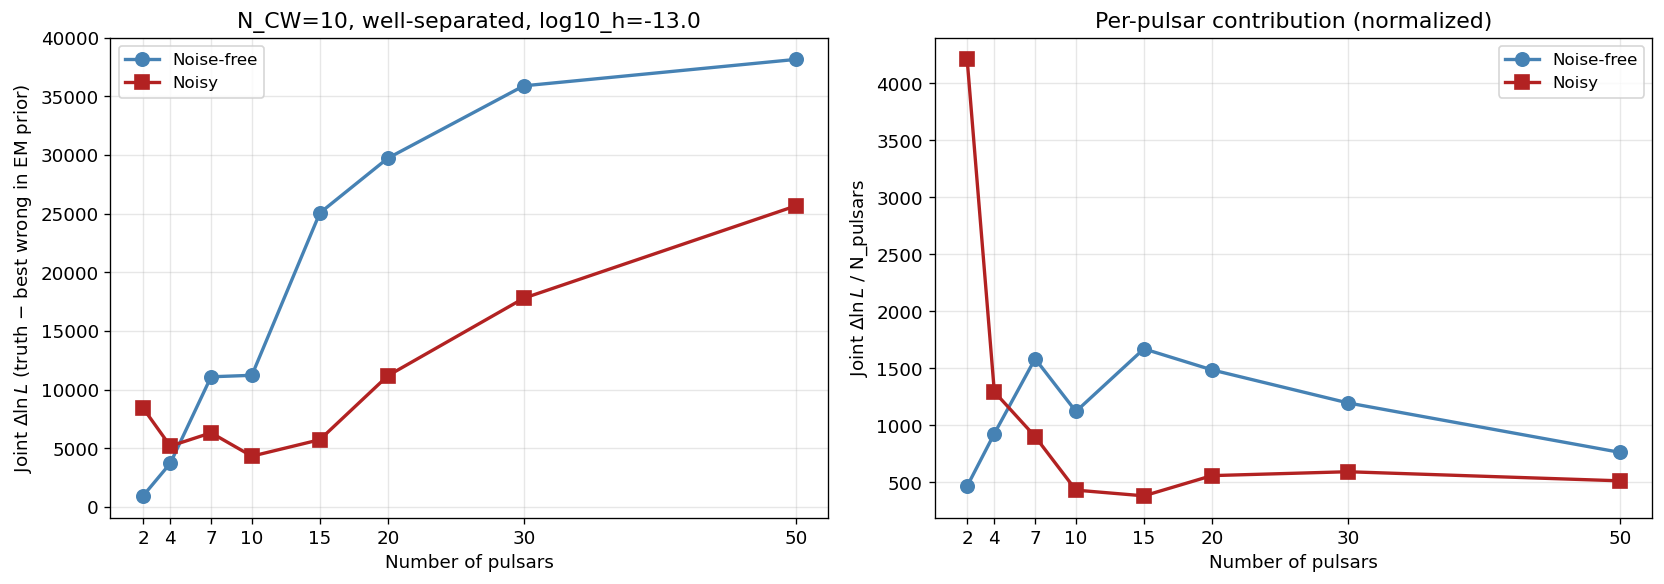

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute Δln L
ax = axes[0]
nf_deltas = [noisefree_results[n]["delta_joint"] for n in npsr_values]
ny_deltas = [noisy_results[n]["delta_joint"] for n in npsr_values]

ax.plot(npsr_values, nf_deltas, "o-", label="Noise-free", lw=2, ms=8, color="steelblue")
ax.plot(npsr_values, ny_deltas, "s-", label="Noisy", lw=2, ms=8, color="firebrick")
ax.set_xlabel("Number of pulsars")
ax.set_ylabel(r"Joint $\Delta \ln L$ (truth $-$ best wrong in EM prior)")
ax.set_title(f"N_CW={ncw}, well-separated, log10_h={log10_h}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(npsr_values)

# Right: Δln L per pulsar (normalized)
ax = axes[1]
nf_per_psr = [noisefree_results[n]["delta_joint"] / n for n in npsr_values]
ny_per_psr = [noisy_results[n]["delta_joint"] / n for n in npsr_values]

ax.plot(npsr_values, nf_per_psr, "o-", label="Noise-free", lw=2, ms=8, color="steelblue")
ax.plot(npsr_values, ny_per_psr, "s-", label="Noisy", lw=2, ms=8, color="firebrick")
ax.set_xlabel("Number of pulsars")
ax.set_ylabel(r"Joint $\Delta \ln L$ / N_pulsars")
ax.set_title(f"Per-pulsar contribution (normalized)")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(npsr_values)

fig.tight_layout()
plt.show()


## 5. Per-pulsar breakdown

Show each pulsar's individual contribution to the joint penalty as the array grows.
This reveals whether some pulsars are much more constraining than others (e.g. due
to tighter EM distance priors or more favourable sky positions relative to the CW
sources).


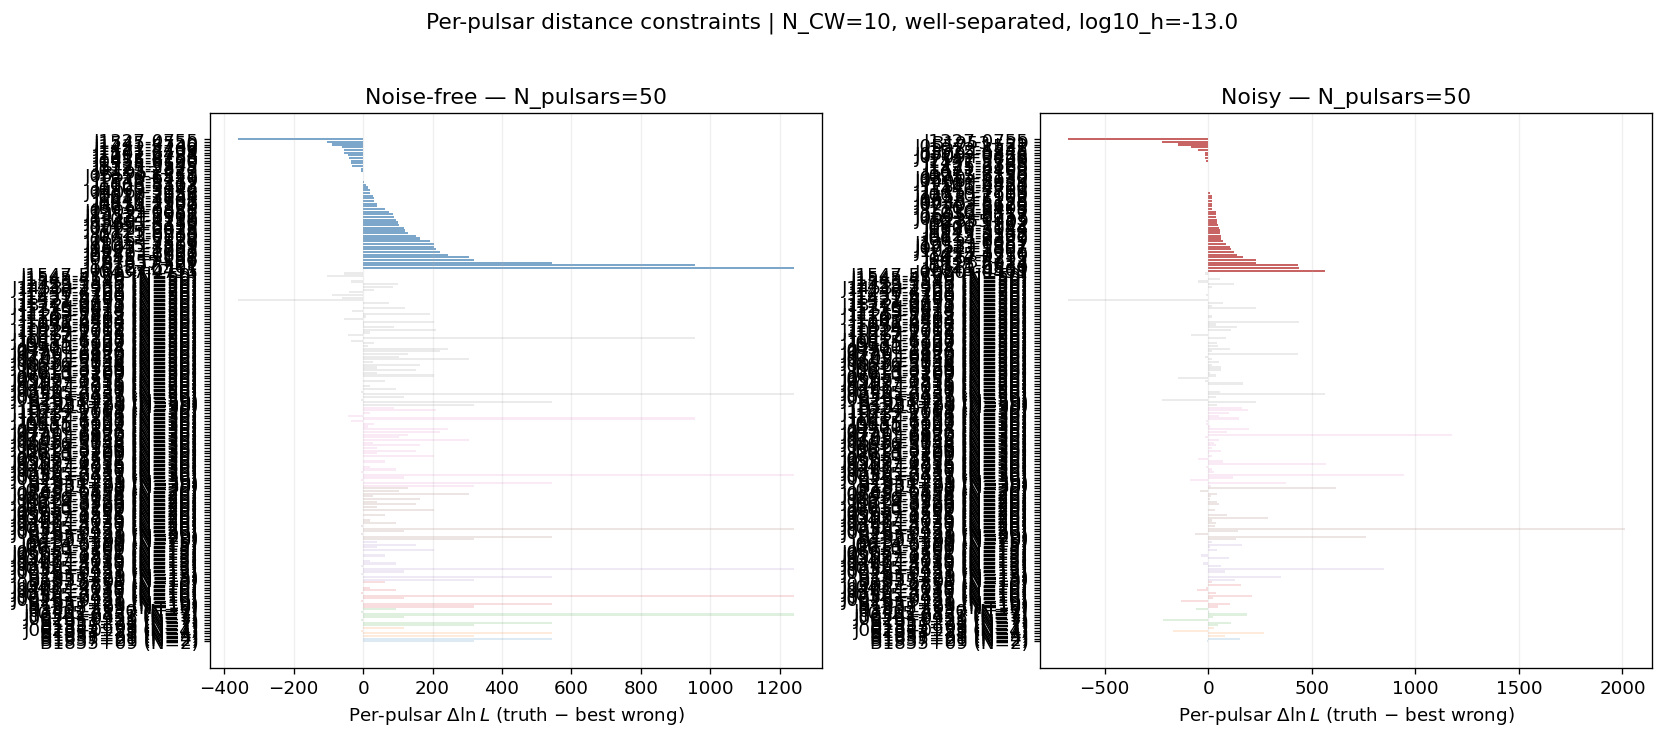

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for col, (results, label) in enumerate([
    (noisefree_results, "Noise-free"),
    (noisy_results, "Noisy"),
]):
    ax = axes[col]

    # Collect per-pulsar Δln L for largest array to rank pulsars
    largest = max(npsr_values)
    psr_names = list(results[largest]["per_pulsar"].keys())
    psr_deltas = {pname: results[largest]["per_pulsar"][pname]["delta_lnL"] for pname in psr_names}
    sorted_psrs = sorted(psr_deltas.keys(), key=lambda x: psr_deltas[x], reverse=True)

    # For each N_pulsars, show cumulative per-pulsar contributions
    for npsr in npsr_values:
        per_psr = results[npsr]["per_pulsar"]
        names = list(per_psr.keys())
        deltas = [per_psr[n]["delta_lnL"] for n in names]
        ax.barh(
            [f"{n} (N={npsr})" for n in names],
            deltas,
            alpha=0.15,
        )

    # Show breakdown for largest array clearly
    per_psr = results[largest]["per_pulsar"]
    names = list(per_psr.keys())
    deltas = [per_psr[n]["delta_lnL"] for n in names]
    sort_idx = np.argsort(deltas)[::-1]
    sorted_names = [names[i] for i in sort_idx]
    sorted_deltas = [deltas[i] for i in sort_idx]

    ax.barh(sorted_names, sorted_deltas, color="steelblue" if col == 0 else "firebrick", alpha=0.7)
    ax.set_xlabel(r"Per-pulsar $\Delta \ln L$ (truth $-$ best wrong)")
    ax.set_title(f"{label} — N_pulsars={largest}")
    ax.grid(True, alpha=0.2, axis="x")

fig.suptitle(f"Per-pulsar distance constraints | N_CW={ncw}, well-separated, log10_h={log10_h}",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## 6. Scaling analysis

Does Δln L scale linearly with N_pulsars (each pulsar contributes independently)
or is there a different scaling?


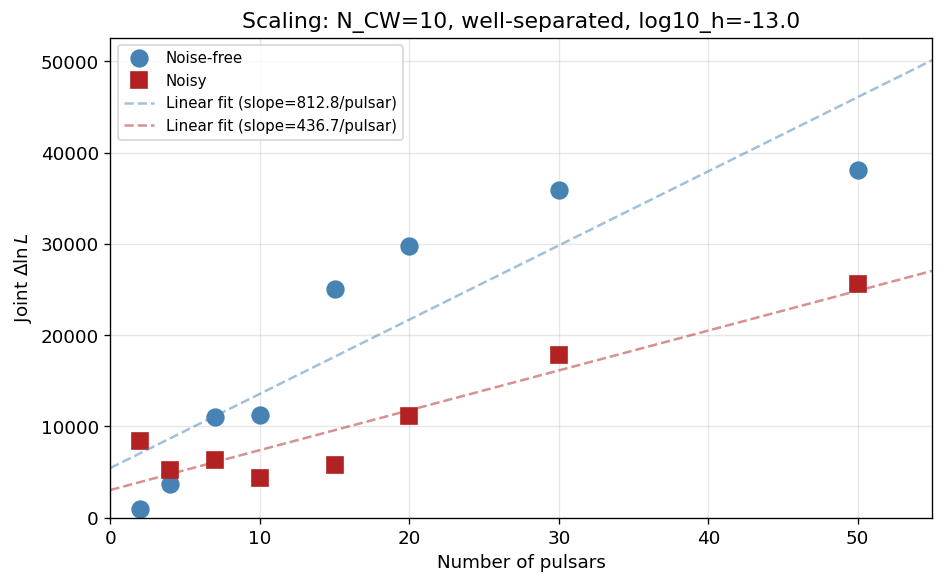

Noise-free: slope = 812.8 Δln L per pulsar, intercept = 5447.7
Noisy:      slope = 436.7 Δln L per pulsar, intercept = 3035.1


In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

nf_deltas = np.array([noisefree_results[n]["delta_joint"] for n in npsr_values])
ny_deltas = np.array([noisy_results[n]["delta_joint"] for n in npsr_values])
npsr_arr = np.array(npsr_values, dtype=float)

# Linear fit
from numpy.polynomial import polynomial as P
nf_coeffs = P.polyfit(npsr_arr, nf_deltas, 1)
ny_coeffs = P.polyfit(npsr_arr, ny_deltas, 1)

ax.plot(npsr_values, nf_deltas, "o", color="steelblue", ms=10, label="Noise-free")
ax.plot(npsr_values, ny_deltas, "s", color="firebrick", ms=10, label="Noisy")

x_fit = np.linspace(0, max(npsr_values) * 1.1, 100)
ax.plot(x_fit, P.polyval(x_fit, nf_coeffs), "--", color="steelblue", alpha=0.5,
        label=f"Linear fit (slope={nf_coeffs[1]:.1f}/pulsar)")
ax.plot(x_fit, P.polyval(x_fit, ny_coeffs), "--", color="firebrick", alpha=0.5,
        label=f"Linear fit (slope={ny_coeffs[1]:.1f}/pulsar)")

ax.set_xlabel("Number of pulsars")
ax.set_ylabel(r"Joint $\Delta \ln L$")
ax.set_title(f"Scaling: N_CW={ncw}, well-separated, log10_h={log10_h}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(npsr_values) * 1.1)
ax.set_ylim(0, None)

fig.tight_layout()
plt.show()

print(f"Noise-free: slope = {nf_coeffs[1]:.1f} Δln L per pulsar, intercept = {nf_coeffs[0]:.1f}")
print(f"Noisy:      slope = {ny_coeffs[1]:.1f} Δln L per pulsar, intercept = {ny_coeffs[0]:.1f}")


## 7. Summary table

In [8]:
print("=" * 90)
print(f"SUMMARY: Joint Delta ln L vs N_pulsars")
print(f"N_CW={ncw}, well-separated, log10_h={log10_h}")
print("=" * 90)

print(f"\n{'N_pulsars':>10s} | {'Noise-free':>14s} | {'Noisy':>14s} | {'NF/pulsar':>12s} | {'Noisy/pulsar':>12s}")
print("-" * 72)
for npsr in npsr_values:
    nf = noisefree_results[npsr]["delta_joint"]
    ny = noisy_results[npsr]["delta_joint"]
    print(f"{npsr:10d} | {nf:14.2f} | {ny:14.2f} | {nf/npsr:12.2f} | {ny/npsr:12.2f}")


SUMMARY: Joint Delta ln L vs N_pulsars
N_CW=10, well-separated, log10_h=-13.0

 N_pulsars |     Noise-free |          Noisy |    NF/pulsar | Noisy/pulsar
------------------------------------------------------------------------
         2 |         932.54 |        8415.40 |       466.27 |      4207.70
         4 |        3707.68 |        5173.64 |       926.92 |      1293.41
         7 |       11084.41 |        6307.37 |      1583.49 |       901.05
        10 |       11210.43 |        4314.63 |      1121.04 |       431.46
        15 |       25052.78 |        5720.97 |      1670.19 |       381.40
        20 |       29722.51 |       11174.97 |      1486.13 |       558.75
        30 |       35893.15 |       17784.32 |      1196.44 |       592.81
        50 |       38144.95 |       25653.66 |       762.90 |       513.07


## Interpretation

- If Δln L scales **linearly** with N_pulsars, each pulsar contributes independently
  to the distance constraint. This would mean the per-pulsar Δln L is roughly constant.

- If Δln L scales **sub-linearly**, additional pulsars provide diminishing returns —
  perhaps because newly added pulsars have worse EM priors or less favourable geometry.

- If Δln L scales **super-linearly**, pulsars are reinforcing each other — the joint
  constraint is more powerful than the sum of individual constraints.

The per-pulsar breakdown (Section 5) reveals which pulsars dominate the constraint
and whether some are effectively free-riders with negligible individual Δln L.
